# Main Report

In [23]:
# Reload all modules before executing the notebook
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [24]:
from utils import set_seed, train_epoch, setup_model

In [31]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt

# Torch for deep learning
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

# Torchvision for datasets and transformations
import torchvision
import torchvision.transforms as transforms
import tqdm

from sklearn.metrics import balanced_accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

set_seed(42)

Using device: cuda


In [4]:
# Imagenet preprocessing
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

# Validation / Test transform
val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

# Load test dataset
test_dataset = torchvision.datasets.ImageFolder('FGVCAircraft_Subset20/test', transform=val_transform)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=4)
class_names = test_dataset.classes
print(f"Number of test samples: {len(test_dataset)}")

Number of test samples: 669


### Compare learning curves across 4 models and select the best model

* **Baseline:** ResNet-18 (Frozen) + SGD
* **H1 (Experiment 1):** ResNet-18 (Unfrozen) + AdamW + CosineAnnealingLR
* **H2 (Experiment 2):** ResNet-50 (Unfrozen) + AdamW + CosineAnnealingLR [WON when epoch = 32]
* **H3 (Experiment 3):** DINOv3 (Linear Probing) + AdamW + CosineAnnealingLR [WON when epoch = 10]

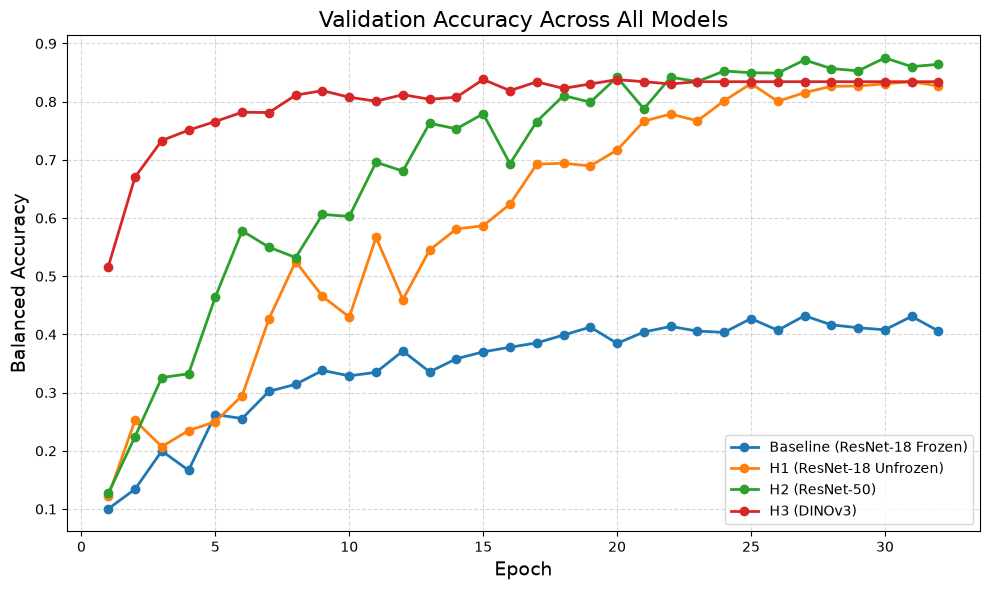


--- Final Model Comparison ---


,Experiment,Final Val Accuracy
0,Baseline (ResNet-18 Frozen),40.58%
1,H1 (ResNet-18 Unfrozen),82.69%
2,H2 (ResNet-50),86.43%
3,H3 (DINOv3),83.43%


In [5]:
models = ['baseline', 'h1', 'h2', 'h3']
labels = ['Baseline (ResNet-18 Frozen)', 'H1 (ResNet-18 Unfrozen)', 'H2 (ResNet-50)', 'H3 (DINOv3)']
model_weights = []

# Load the pickle files
for exp in models:
    try:
        with open(f'weights_model_{exp}.pkl', 'rb') as f:
            model_weights.append(pickle.load(f))
    except FileNotFoundError:
        print(f"Warning: model_weights_{exp}.pkl not found! Please run development_{exp}.ipynb first.")
        model_weights.append(None)

# Reset to default matplotlib style
# plt.style.use('default')
plt.figure(figsize=(10, 6))

final_accuracies = []
for i, hist in enumerate(model_weights):
    if hist is not None:
        val_acc = hist['val_acc']
        epochs = range(1, len(val_acc) + 1)
        plt.plot(epochs, val_acc, marker='o', linewidth=2, label=labels[i])
        final_accuracies.append(val_acc[-1])
    else:
        final_accuracies.append(0.0)

plt.title('Validation Accuracy Across All Models', fontsize=16)
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Balanced Accuracy', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Print Summary Table
print("\n--- Final Model Comparison ---")
df = pd.DataFrame({
    'Experiment': labels,
    'Final Val Accuracy': [f"{acc*100:.2f}%" for acc in final_accuracies]
})
display(df)

### Retrain the best model on the whole TrainVal dataset

In [6]:
# Data augmentation for training dataset
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

# Load the FULL trainval dataset (100% data, no splitting)
full_trainval_dataset = torchvision.datasets.ImageFolder('FGVCAircraft_Subset20/trainval', transform=train_transform)
full_train_loader = torch.utils.data.DataLoader(full_trainval_dataset, batch_size=16, shuffle=True, num_workers=4)

print(f"Number of total training samples: {len(full_trainval_dataset)}")

Number of total training samples: 1331


In [7]:
backbone_model = torchvision.models.resnet50(weights=torchvision.models.ResNet50_Weights.DEFAULT)
final_model = setup_model(backbone_model, 20, freeze_backbone=False, device=device)
print("Initialized Unfrozen ResNet-50")
final_model

Initialized Unfrozen ResNet-50


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Con

In [8]:
# # Model Setup
# REPO_DIR = './dinov3'
# WEIGHTS_PATH = './weights/dinov3_vits16_pretrain_lvd1689m-08c60483.pth'

# class DinoV3Classifier(nn.Module):
#     def __init__(self, repo_dir, weights, num_classes=20, freeze_backbone=True):
#         super().__init__()
#         # Load local DINOv3 ViT-S/16 with pre-trained weights
#         self.backbone = torch.hub.load(
#             repo_dir,
#             'dinov3_vits16',
#             source='local',
#             weights=weights
#         )
#         embed_dim = getattr(self.backbone, 'embed_dim', 384)
#         self.fc = nn.Linear(embed_dim, num_classes)
        
#         # Linear Probing: freeze the backbone!
#         if freeze_backbone:
#             for param in self.backbone.parameters():
#                 param.requires_grad = False

#     def forward(self, x):
#         features = self.backbone(x)
#         return self.fc(features)

# # Initialize DinoV3
# final_model = DinoV3Classifier(repo_dir=REPO_DIR, weights=WEIGHTS_PATH, num_classes=20, freeze_backbone=True).to(device)
# print("Initialized fresh DINOv3 model for retraining on full trainval dataset.")

In [9]:
# Retrain on full trainval dataset
lr = 0.001
total_epochs = 32

# Define a loss function
criterion = nn.CrossEntropyLoss()

# Initialise the AdamW optimizer (filter out frozen parameters)
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, final_model.parameters()), lr=lr, weight_decay=1e-4
)

# Initialize Cosine Annealing Learning Rate Scheduler
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=total_epochs)

epoch_pbar = tqdm.tqdm(range(total_epochs), colour='blue')
for epoch in epoch_pbar:
    mean_train_loss, train_accuracy = train_epoch(
        final_model, full_train_loader, criterion, optimizer, epoch, device
    )
    scheduler.step()
    epoch_pbar.write(f"Epoch [{epoch+1:3d}/{total_epochs}] | train_loss: {mean_train_loss:.4f} | train_acc: {train_accuracy:.4f}")
print("Retraining Complete!")

  3%|▎         | 1/32 [00:25<13:04, 25.30s/it]

Epoch [  1/32] | train_loss: 2.6206 | train_acc: 0.1758


  6%|▋         | 2/32 [00:50<12:34, 25.16s/it]

Epoch [  2/32] | train_loss: 2.2201 | train_acc: 0.2682


  9%|▉         | 3/32 [01:15<12:06, 25.04s/it]

...

Epoch [ 30/32] | train_loss: 0.2041 | train_acc: 0.9346


 97%|█████████▋| 31/32 [12:54<00:25, 25.17s/it]

Epoch [ 31/32] | train_loss: 0.2428 | train_acc: 0.9331


100%|██████████| 32/32 [13:20<00:00, 25.00s/it]

Epoch [ 32/32] | train_loss: 0.2349 | train_acc: 0.9361
Retraining Complete!


### Evaluate the best model on Test Set

In [29]:
def evaluate_on_test(model, dataloader, device):
    model.eval()
    all_labels = []
    all_preds = []

    all_probs = []
    with torch.no_grad():
        for i, data in tqdm.tqdm(enumerate(dataloader, 0), total=len(dataloader), desc="Evaluating on Test Set"):
            inputs, labels = data
            inputs = inputs.to(device)
            
            outputs = model(inputs)
            probs = F.softmax(outputs, dim=1)
            predicted = torch.argmax(outputs, dim=1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    # Calculate average per-class accuracy (balanced accuracy)
    test_accuracy = balanced_accuracy_score(all_labels, all_preds)
    print(f"\nAverge per-class accuracy on Test Set using the best model: {test_accuracy:.4f}")
    
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names))
    
    return all_labels, all_preds, all_probs, test_accuracy

all_labels, all_preds, all_probs, test_accuracy = evaluate_on_test(final_model, test_loader, device)

Evaluating on Test Set: 100%|██████████| 42/42 [00:03<00:00, 10.83it/s]


Averge per-class accuracy on Test Set using the best model: 0.8804

Classification Report:
              precision    recall  f1-score   support

    class_00       0.66      0.56      0.60        34
    class_01       0.62      0.70      0.66        33
    class_02       1.00      0.94      0.97        33
    class_03       0.88      0.88      0.88        34
    class_04       0.97      0.94      0.96        34
    class_05       0.89      0.73      0.80        33
    class_06       0.87      0.97      0.92        34
    class_07       1.00      0.94      0.97        33
    class_08       0.97      0.88      0.92        34
    class_09       0.91      0.94      0.93        33
    class_10       0.94      0.94      0.94        34
    class_11       0.89      1.00      0.94        33
    class_12       0.86      0.91      0.88        33
    class_13       0.89      0.94      0.91        33
    class_14       0.94      0.91      0.93        34
    class_15       0.89      0.94      0.91

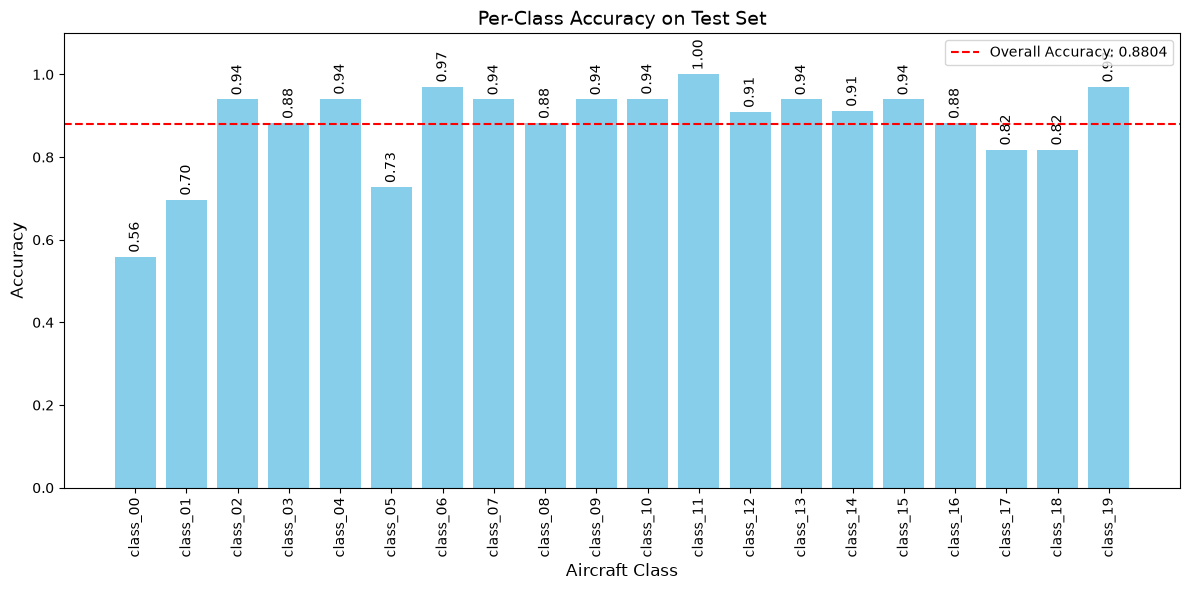

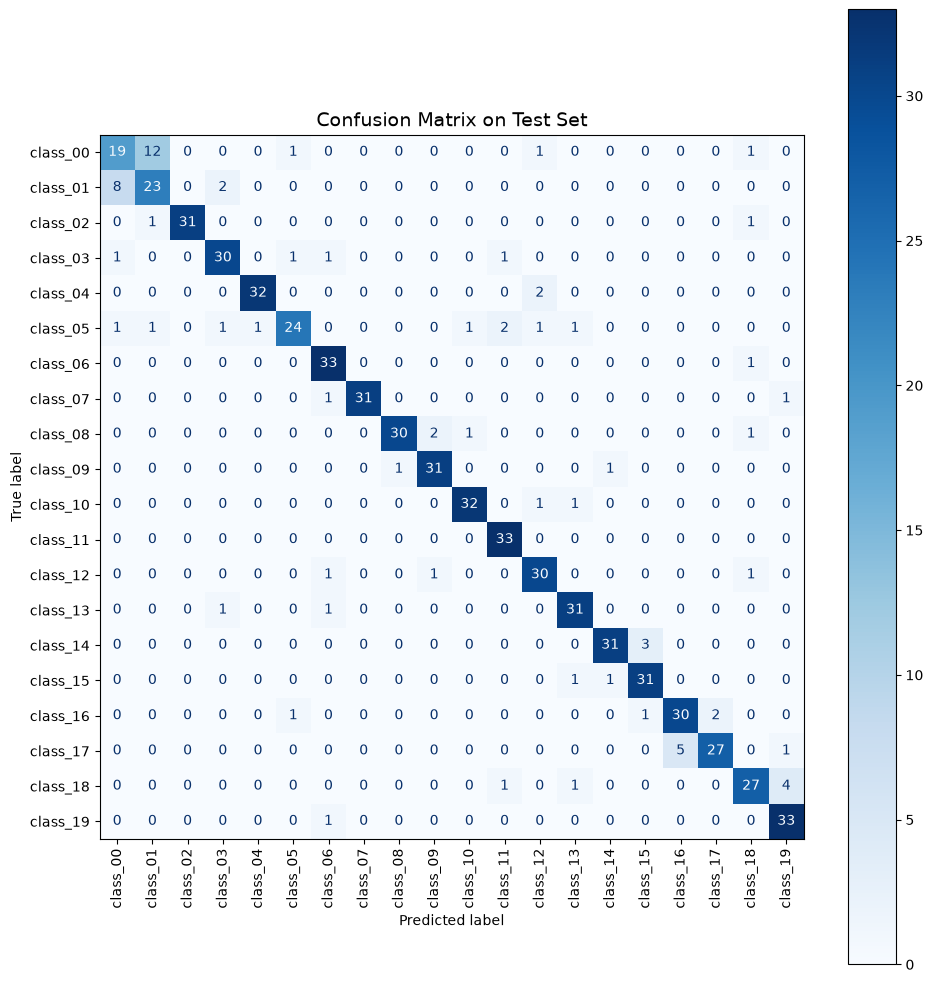

In [28]:
# Compute confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Compute per-class accuracy
per_class_acc = cm.diagonal() / cm.sum(axis=1)

# 1. Plot Per-Class Accuracy Bar Chart
plt.figure(figsize=(12, 6))
plt.bar(class_names, per_class_acc, color='skyblue')
plt.xlabel('Aircraft Class', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Per-Class Accuracy on Test Set', fontsize=14)
plt.xticks(rotation=90)
plt.ylim(0, 1.1)
plt.axhline(y=test_accuracy, color='r', linestyle='--', label=f'Overall Accuracy: {test_accuracy:.4f}')

# Add text labels above the bars
for i, acc in enumerate(per_class_acc):
    plt.text(i, acc + 0.01, f"{acc:.2f}", ha='center', va='bottom', rotation=90, fontsize=10)
plt.legend()
plt.tight_layout()
plt.show()

# 2. Plot Confusion Matrix
fig, ax = plt.subplots(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation='vertical')
ax.grid(False)
plt.title('Confusion Matrix on Test Set', fontsize=14)
plt.tight_layout()
plt.show()
